# 06. Recurrent Neural Networks (RNN)
**Algorithms implemented:** Vanilla RNN (Elman) and LSTM in PyTorch.

**Dataset:** Monthly Airline Passengers (`data/airline_passengers.csv`) - 12-month sliding windows forecast the next month.


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Scaling + regression metrics ----
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# ---- PyTorch for the recurrent models ----
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Aesthetics setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

# Reproducibility
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)  # reproducible GPU training
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__} on {device}")

# ---- Load the monthly airline passengers time series ----
df_air = pd.read_csv('../data/airline_passengers.csv')
print("Dataset Head:")
display(df_air.head())

# Extract the target series as float32 (shape: N x 1)
passengers = df_air['Passengers'].values.astype(np.float32).reshape(-1, 1)
# ---- Normalize to [0, 1] (RNNs train much better on small inputs) ----
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(passengers)

# ---- Function to build supervised sliding-window sequences ----
# For each time step t: X = values [t-seq_len ... t-1], y = value at t
def create_sequences(data, seq_length=12):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 12  # 12-month lookback = one full annual seasonal cycle
X_seq, y_seq = create_sequences(scaled_data, seq_length=SEQ_LENGTH)

# ---- Temporal split: 80% train, 20% test WITHOUT shuffling (time order matters) ----
train_size = int(len(X_seq) * 0.80)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

print(f"Total sequences created: {len(X_seq)}")
print(f"Training sequences:      {X_train.shape[0]} (Shape: {X_train.shape})")
print(f"Testing sequences:       {X_test.shape[0]}  (Shape: {X_test.shape})")

# ---- DataLoader for mini-batch training (shuffle only the training set) ----
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
    batch_size=16,
    shuffle=True
)


PyTorch version: 2.14.0+cu126 on cuda
Dataset Head:


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Total sequences created: 132
Training sequences:      105 (Shape: (105, 12, 1))
Testing sequences:       27  (Shape: (27, 12, 1))


## 1. Model Architectures

### Step-by-Step Algorithm (Vanilla RNN)
1. Start with an initial hidden state h₀ (usually zeros).
2. For each time step t: h_t = tanh(W_ih x_t + b_ih + W_hh h_{t-1} + b_hh).
3. Keep only the final hidden state h_T and map it to the forecast: ŷ = W_ho h_T + b_o.
4. Train with backpropagation through time (BPTT): gradients flow backwards through every time step.
5. Limitation: repeated multiplication makes gradients vanish/explode on long sequences.

### Step-by-Step Algorithm (LSTM)
1. At each step compute the **forget gate** f_t (what to discard from the cell state).
2. Compute the **input gate** i_t and candidate memory c̃_t (what new information to store).
3. Update the cell state: c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t (additive "conveyor belt").
4. Compute the **output gate** o_t and hidden state: h_t = o_t ⊙ tanh(c_t).
5. Predict from the last hidden state as in the vanilla RNN.
6. Train with BPTT - the additive cell state lets gradients flow across long horizons.

### Training Process (shared)
1. Normalize the series and cut it into sliding windows of 12 months (one seasonal cycle).
2. Split chronologically: first 80% for training, last 20% for testing.
3. For every epoch: forward pass through the recurrent layers, MSE loss, BPTT, Adam update.
4. Track the loss per epoch to compare convergence of RNN vs LSTM.

In [2]:
class VanillaRNN(nn.Module):
    """Elman RNN: 2 stacked recurrent layers + a linear output layer."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)   # map final hidden state to a scalar forecast

    def forward(self, x):
        out, _ = self.rnn(x)                 # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])         # use ONLY the last time step's hidden state
        return out

class LSTMModel(nn.Module):
    """LSTM: same interface, but gated cells preserve long-term information."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Instantiate both models on the selected device so they can be compared fairly
rnn_model = VanillaRNN().to(device)
lstm_model = LSTMModel().to(device)
print("Models instantiated successfully!")


Models instantiated successfully!

In [3]:
# ---- Generic training function shared by both architectures ----
def train_model(model, loader, epochs=120, lr=0.005):
    criterion = nn.MSELoss()                          # regression -> mean squared error
    optimizer = optim.Adam(model.parameters(), lr=lr) # Adam optimizer
    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)

            optimizer.zero_grad()          # clear previous gradients
            pred = model(x_b)              # forward pass through the recurrent net
            loss = criterion(pred, y_b)    # MSE between forecast and truth
            loss.backward()                # backpropagation through time (BPTT)
            optimizer.step()               # update weights

            total_loss += loss.item() * len(x_b)   # de-average the batch loss

        epoch_loss = total_loss / len(loader.dataset)
        losses.append(epoch_loss)          # track loss per epoch for plotting

    return losses

# ---- Train both architectures with identical hyperparameters ----
print("Training Vanilla RNN...")
rnn_losses = train_model(rnn_model, train_loader, epochs=120, lr=0.005)

print("Training LSTM Model...")
lstm_losses = train_model(lstm_model, train_loader, epochs=120, lr=0.005)
print("Training completed!")


Training Vanilla RNN...


Training LSTM Model...


Training completed!


## 2. Evaluation & Forecast

### Evaluation & Forecasting Process
1. Switch both models to evaluation mode and disable gradient computation.
2. Predict all test windows, then invert the MinMax scaling to recover real passenger counts.
3. Compute RMSE and MAE per model in the original unit.
4. Plot the forecast trajectories against the ground truth to inspect trend/seasonality fit.

Time Series Forecasting Performance Comparison:


,RMSE (Passengers),MAE (Passengers)
Model,,
Vanilla RNN,69.927299,62.355827
LSTM Network,44.122326,36.775242


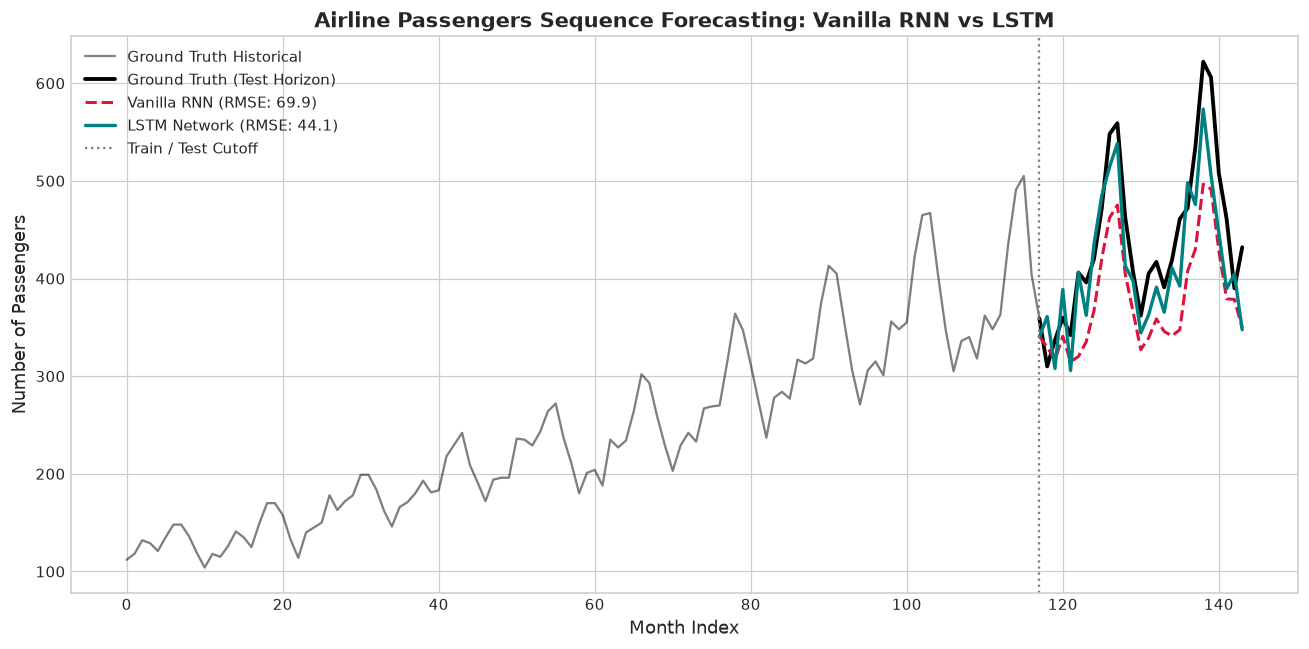

In [4]:
# ---- Evaluate both models on the test horizon ----
rnn_model.eval()
lstm_model.eval()

with torch.no_grad():   # inference only - no gradients
    x_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    pred_rnn_scaled = rnn_model(x_test_t).cpu().numpy()    # normalized predictions
    pred_lstm_scaled = lstm_model(x_test_t).cpu().numpy()

# ---- Invert scaling to get real passenger counts ----
y_test_true = scaler.inverse_transform(y_test)
pred_rnn = scaler.inverse_transform(pred_rnn_scaled)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled)

# ---- Compute error metrics in the original unit (passengers) ----
rmse_rnn = root_mean_squared_error(y_test_true, pred_rnn)
mae_rnn  = mean_absolute_error(y_test_true, pred_rnn)

rmse_lstm = root_mean_squared_error(y_test_true, pred_lstm)
mae_lstm  = mean_absolute_error(y_test_true, pred_lstm)

# ---- Summary table (lower errors are better) ----
eval_df = pd.DataFrame([
    {"Model": "Vanilla RNN", "RMSE (Passengers)": rmse_rnn, "MAE (Passengers)": mae_rnn},
    {"Model": "LSTM Network", "RMSE (Passengers)": rmse_lstm, "MAE (Passengers)": mae_lstm}
]).set_index("Model")

print("Time Series Forecasting Performance Comparison:")
display(eval_df.style.highlight_min(subset=['RMSE (Passengers)', 'MAE (Passengers)'], color='lightgreen'))

# ---- Plot ground truth vs. both forecast trajectories ----
# Map each test target back to its true position on the month axis:
# sequence i predicts month (i + SEQ_LENGTH)
test_indices = range(train_size + SEQ_LENGTH, len(passengers))

plt.figure(figsize=(12, 6))
# Full historical series in the background
plt.plot(range(len(passengers)), passengers, label='Ground Truth Historical', color='black', alpha=0.5, lw=1.5)

# Test-period ground truth
plt.plot(test_indices, y_test_true, label='Ground Truth (Test Horizon)', color='black', lw=2.5)

# Model forecasts
plt.plot(test_indices, pred_rnn, label=f'Vanilla RNN (RMSE: {rmse_rnn:.1f})', color='crimson', lw=2, linestyle='--')
plt.plot(test_indices, pred_lstm, label=f'LSTM Network (RMSE: {rmse_lstm:.1f})', color='teal', lw=2.2)

# Vertical line marking where the train period ends and test begins
plt.axvline(x=train_size + SEQ_LENGTH, color='gray', linestyle=':', label='Train / Test Cutoff')
plt.title("Airline Passengers Sequence Forecasting: Vanilla RNN vs LSTM", fontsize=14, fontweight='bold')
plt.xlabel("Month Index", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()
